# Notebook 03 – Transformer Model Training & Evaluation

**Pipeline stages covered:**
1. Load pre-processed splits from Notebook 02
2. Build PyTorch DataLoaders
3. Instantiate Transformer classifier
4. Training loop with live progress
5. Loss & accuracy curves
6. Evaluation: Accuracy · Precision · Recall · F1-Score
7. Confusion matrix (raw + normalized)
8. Per-class metrics bar chart & radar chart
9. ROC curves (one-vs-rest)
10. Save model + all artifacts to `model/`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import joblib
from sklearn.metrics import classification_report, confusion_matrix

from utils.model_utils import (
    TransformerClassifier,
    make_dataloaders,
    train_model,
    eval_epoch,
    compute_metrics,
    save_model,
)
from utils.visualization import (
    plot_training_history,
    plot_confusion_matrix,
    plot_evaluation_metrics,
    plot_metrics_radar,
    plot_roc_curves,
)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'✓ Imports OK  |  Device: {device}')

✓ Imports OK  |  Device: cpu


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────
DATA_DIR   = '../../data/processed-ids2017'
MODEL_DIR  = '../../model/ddos-ids2017'

# Transformer hyperparameters
D_MODEL        = 128
N_HEADS        = 4
N_LAYERS       = 2
DIM_FEEDFORWARD= 256
DROPOUT        = 0.1

# Training hyperparameters
N_EPOCHS       = 10
BATCH_SIZE     = 512
LEARNING_RATE  = 1e-3
RANDOM_STATE   = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.makedirs(MODEL_DIR, exist_ok=True)
print('Configuration set.')

Configuration set.


## 1 · Load Pre-processed Splits

In [3]:
with open(f'{DATA_DIR}/metadata.json') as f:
    meta = json.load(f)

class_names       = meta['class_names']
selected_features = meta['selected_features']
n_classes         = meta['n_classes']
n_features        = meta['n_features']

X_train = np.load(f'{DATA_DIR}/X_train_sc.npy')
X_test  = np.load(f'{DATA_DIR}/X_test_sc.npy')
y_train = np.load(f'{DATA_DIR}/y_train_enc.npy')
y_test  = np.load(f'{DATA_DIR}/y_test_enc.npy')

y_train_raw = pd.read_json(f'{DATA_DIR}/y_train_raw.json', typ='series')
y_test_raw  = pd.read_json(f'{DATA_DIR}/y_test_raw.json',  typ='series')

scaler        = joblib.load(f'{MODEL_DIR}/scaler.pkl')
label_encoder = joblib.load(f'{MODEL_DIR}/label_encoder.pkl')

print(f'Classes ({n_classes}): {class_names}')
print(f'Selected features ({n_features}): {selected_features}')
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

Classes (14): ['BENIGN', 'DNS', 'LDAP', 'MSSQL', 'NTP', 'NetBIOS', 'Portmap', 'SNMP', 'SSDP', 'Syn', 'TFTP', 'UDP', 'UDPLag', 'WebDDoS']
Selected features (20): ['Min Packet Length', 'Average Packet Size', 'Max Packet Length', 'Fwd IAT Max', 'Packet Length Mean', 'Fwd Packet Length Max', 'Avg Fwd Segment Size', 'Fwd Packet Length Min', 'Fwd IAT Std', 'Fwd IAT Total', 'Fwd Packet Length Mean', 'Flow Duration', 'Fwd IAT Mean', 'Subflow Fwd Bytes', 'Flow IAT Std', 'act_data_pkt_fwd', 'Total Fwd Packets', 'Flow IAT Max', 'Total Length of Fwd Packets', 'Flow Packets/s']
X_train: (745017, 20)  y_train: (745017, 14)
X_test : (186255, 20)   y_test : (186255, 14)


## 2 · Build DataLoaders

In [4]:
train_loader, test_loader = make_dataloaders(
    X_train, y_train,
    X_test,  y_test,
    batch_size=BATCH_SIZE,
)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 1456  |  Test batches: 364


## 3 · Instantiate Transformer Classifier

In [5]:
model = TransformerClassifier(
    n_features=n_features,
    n_classes=n_classes,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

TransformerClassifier(
  (input_proj): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=128, out_features

## 4 · Training

In [6]:
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    n_epochs=N_EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    verbose=True,
)

Epoch   1/10 │ Train Loss: 0.0717  Acc: 0.7659 │ Val Loss: 0.0778  Acc: 0.7589 │ LR: 9.76e-04
Epoch   2/10 │ Train Loss: 0.0575  Acc: 0.7997 │ Val Loss: 0.0553  Acc: 0.8052 │ LR: 9.05e-04
Epoch   3/10 │ Train Loss: 0.0559  Acc: 0.8041 │ Val Loss: 0.0549  Acc: 0.8051 │ LR: 7.94e-04
Epoch   4/10 │ Train Loss: 0.0549  Acc: 0.8066 │ Val Loss: 0.0546  Acc: 0.8049 │ LR: 6.55e-04
Epoch   5/10 │ Train Loss: 0.0542  Acc: 0.8084 │ Val Loss: 0.0539  Acc: 0.8081 │ LR: 5.00e-04
Epoch   6/10 │ Train Loss: 0.0531  Acc: 0.8112 │ Val Loss: 0.0511  Acc: 0.8188 │ LR: 3.45e-04
Epoch   7/10 │ Train Loss: 0.0518  Acc: 0.8144 │ Val Loss: 0.0507  Acc: 0.8159 │ LR: 2.06e-04
Epoch   8/10 │ Train Loss: 0.0508  Acc: 0.8173 │ Val Loss: 0.0501  Acc: 0.8175 │ LR: 9.55e-05
Epoch   9/10 │ Train Loss: 0.0503  Acc: 0.8196 │ Val Loss: 0.0496  Acc: 0.8189 │ LR: 2.45e-05
Epoch  10/10 │ Train Loss: 0.0498  Acc: 0.8213 │ Val Loss: 0.0492  Acc: 0.8221 │ LR: 0.00e+00


## 5 · Training History

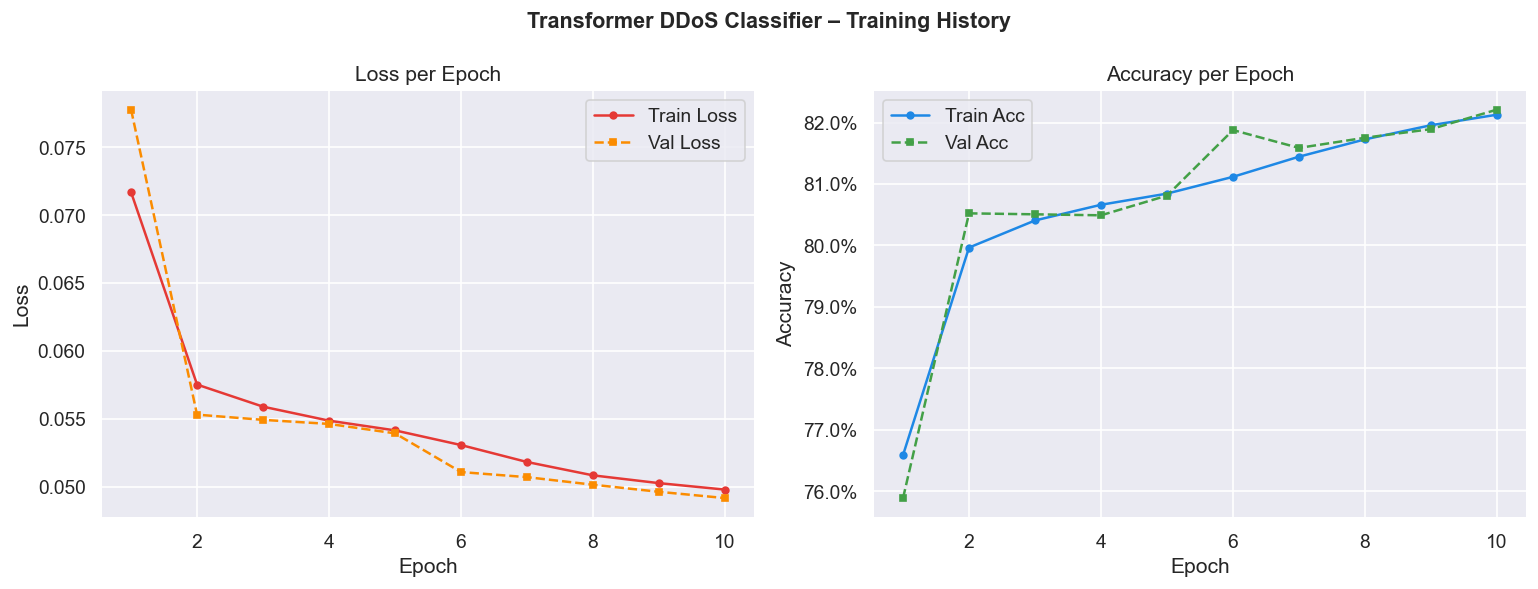

Best train acc : 0.8213
Best val acc   : 0.8221
Best val loss  : 0.0492


In [7]:
fig = plot_training_history(history, title='Transformer DDoS Classifier – Training History')
fig.savefig(f'{DATA_DIR}/fig_12_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

best_train_acc = max(history['train_acc'])
best_val_acc   = max(history['val_acc'])
best_val_loss  = min(history['val_loss'])
print(f'Best train acc : {best_train_acc:.4f}')
print(f'Best val acc   : {best_val_acc:.4f}')
print(f'Best val loss  : {best_val_loss:.4f}')

## 6 · Final Evaluation on Test Set

In [8]:
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()
test_loss, test_acc, y_pred_idx, y_true_idx, y_probs = eval_epoch(
    model, test_loader, criterion, device
)

print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Loss     : 0.0492
Test Accuracy : 0.8221  (82.21%)


In [9]:
# Full classification report
metrics = compute_metrics(y_true_idx, y_pred_idx, class_names)

print('=== Classification Report ===')
print(classification_report(
    y_true_idx, y_pred_idx,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

=== Classification Report ===
              precision    recall  f1-score   support

      BENIGN     0.9632    0.9748    0.9690     30000
         DNS     0.5581    0.3955    0.4629      4903
        LDAP     0.5354    0.0606    0.1089      1996
       MSSQL     0.8663    0.9470    0.9048     19150
         NTP     0.9895    0.9931    0.9913     22600
     NetBIOS     0.7430    0.4439    0.5557      1140
     Portmap     0.0000    0.0000    0.0000        85
        SNMP     0.5599    0.8755    0.6830      4882
        SSDP     0.4997    0.0381    0.0708     23124
         Syn     0.9516    0.9600    0.9558     16233
        TFTP     0.9993    0.9955    0.9974     30000
         UDP     0.5673    0.9613    0.7135     30000
      UDPLag     0.9365    0.6231    0.7483      2059
     WebDDoS     0.2581    0.0964    0.1404        83

    accuracy                         0.8221    186255
   macro avg     0.6734    0.5975    0.5930    186255
weighted avg     0.8117    0.8221    0.7800    186

## 7 · Confusion Matrix

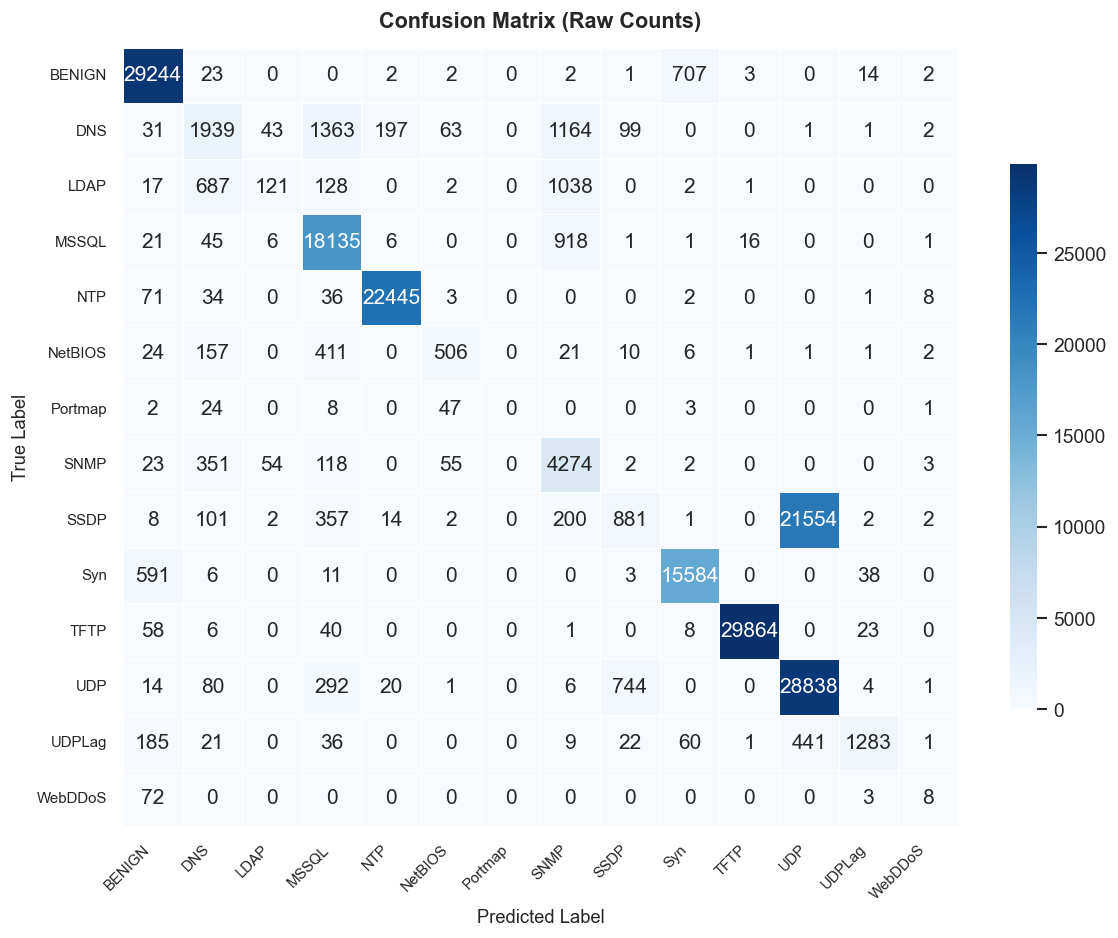

In [10]:
cm = metrics['confusion_matrix']

# Raw counts
fig = plot_confusion_matrix(cm, class_names,
                             title='Confusion Matrix (Raw Counts)',
                             normalize=False)
fig.savefig(f'{DATA_DIR}/fig_13_cm_raw.png', dpi=120, bbox_inches='tight')
plt.show()

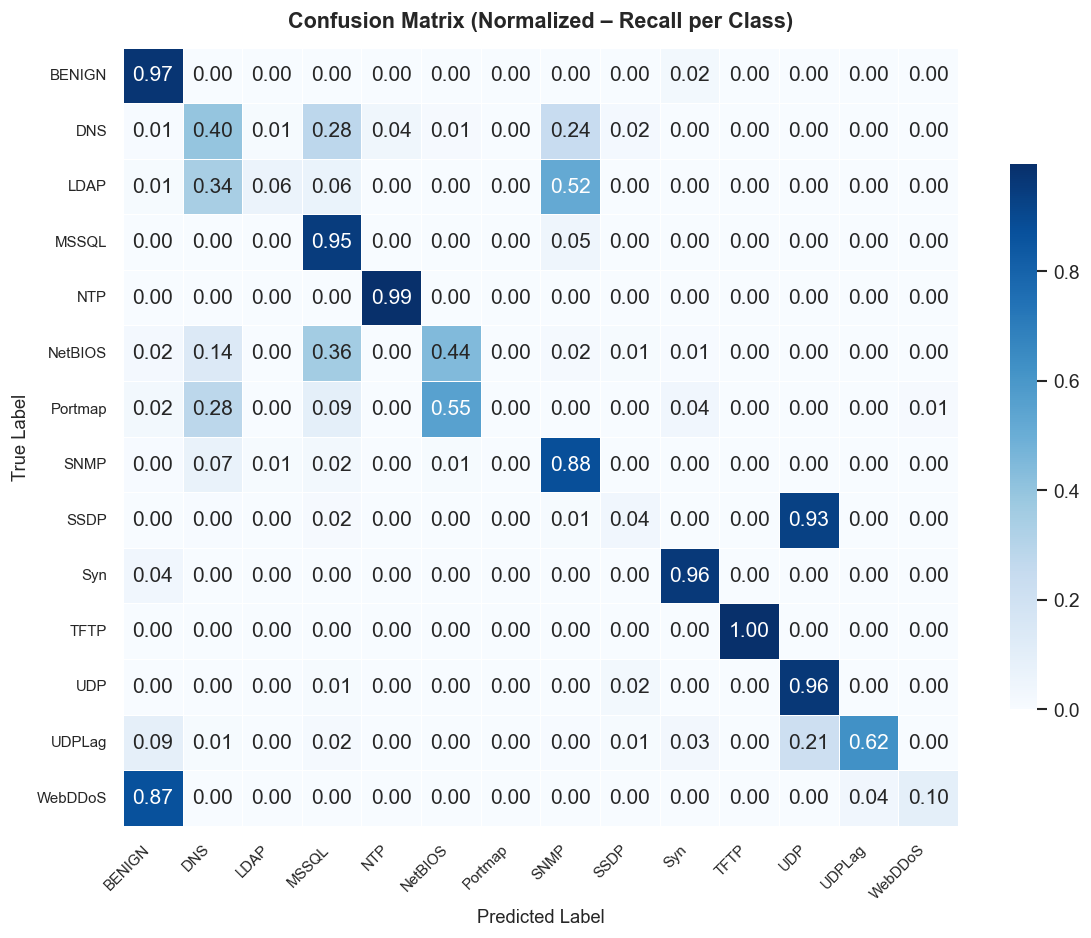

In [11]:
# Normalized (recall per class)
fig = plot_confusion_matrix(cm, class_names,
                             title='Confusion Matrix (Normalized – Recall per Class)',
                             normalize=True)
fig.savefig(f'{DATA_DIR}/fig_14_cm_normalized.png', dpi=120, bbox_inches='tight')
plt.show()

## 8 · Evaluation Metrics – Bar Chart & Radar Chart

In [12]:
# Summary table
skip_keys = {'accuracy', 'macro avg', 'weighted avg', 'confusion_matrix'}
metrics_table = {
    cls: {k: round(v, 4) for k, v in vals.items() if k != 'support'}
    for cls, vals in metrics.items()
    if cls not in skip_keys
}
metrics_table['accuracy'] = round(metrics['accuracy'], 4)
metrics_table['macro avg']    = {k: round(v, 4) for k, v in metrics['macro avg'].items()    if k != 'support'}
metrics_table['weighted avg'] = {k: round(v, 4) for k, v in metrics['weighted avg'].items() if k != 'support'}

summary_df = pd.DataFrame(metrics_table).T
print('=== Metrics Summary ===')
display(summary_df.style.background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1))

=== Metrics Summary ===


,precision,recall,f1-score
BENIGN,0.963200,0.974800,0.969000
DNS,0.558100,0.395500,0.462900
LDAP,0.535400,0.060600,0.108900
MSSQL,0.866300,0.947000,0.904800
NTP,0.989500,0.993100,0.991300
NetBIOS,0.743000,0.443900,0.555700
Portmap,0.000000,0.000000,0.000000
SNMP,0.559900,0.875500,0.683000
SSDP,0.499700,0.038100,0.070800
Syn,0.951600,0.960000,0.955800


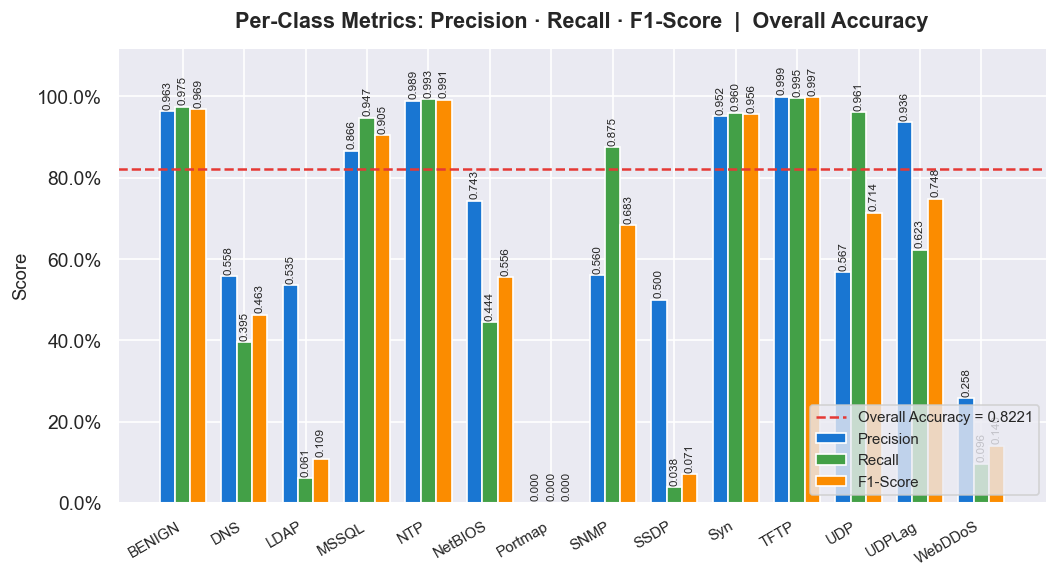

In [13]:
# Grouped bar chart: Precision, Recall, F1 per class
fig = plot_evaluation_metrics(
    metrics,
    title='Per-Class Metrics: Precision · Recall · F1-Score  |  Overall Accuracy'
)
fig.savefig(f'{DATA_DIR}/fig_15_metrics_bar.png', dpi=120, bbox_inches='tight')
plt.show()

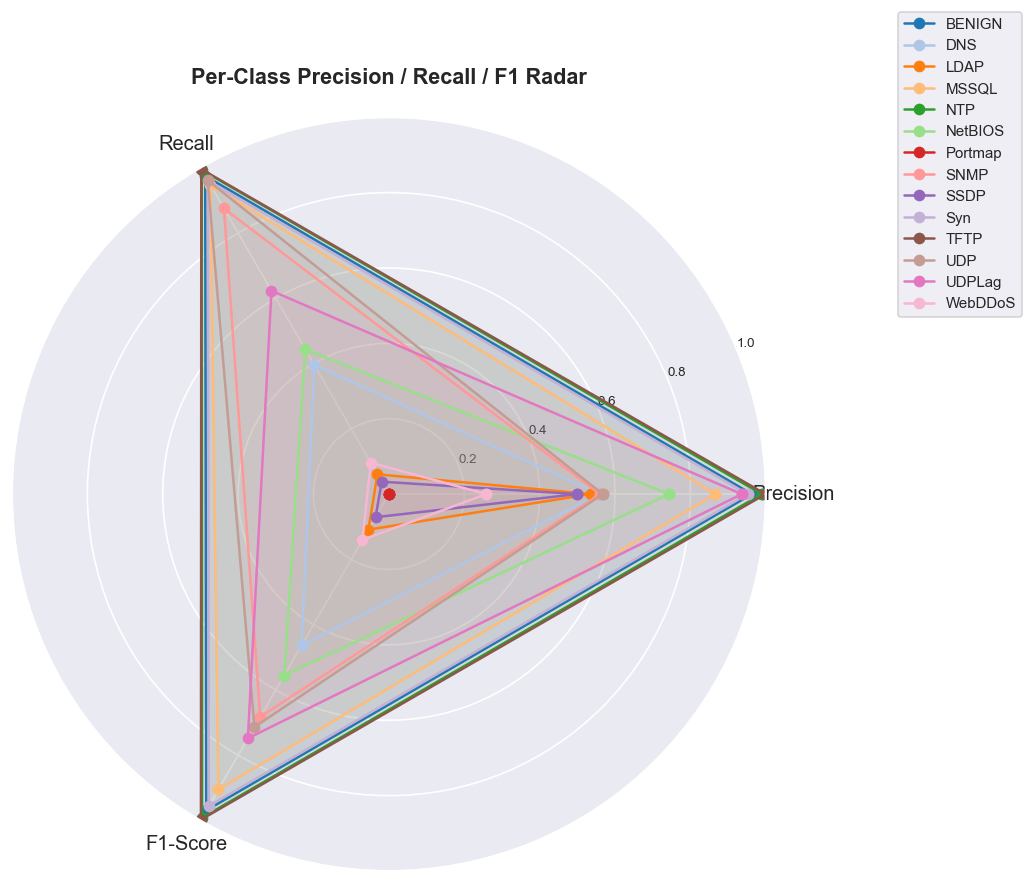

In [14]:
# Radar chart
fig = plot_metrics_radar(metrics, title='Per-Class Precision / Recall / F1 Radar')
fig.savefig(f'{DATA_DIR}/fig_16_metrics_radar.png', dpi=120, bbox_inches='tight')
plt.show()

## 9 · ROC Curves (One-vs-Rest)

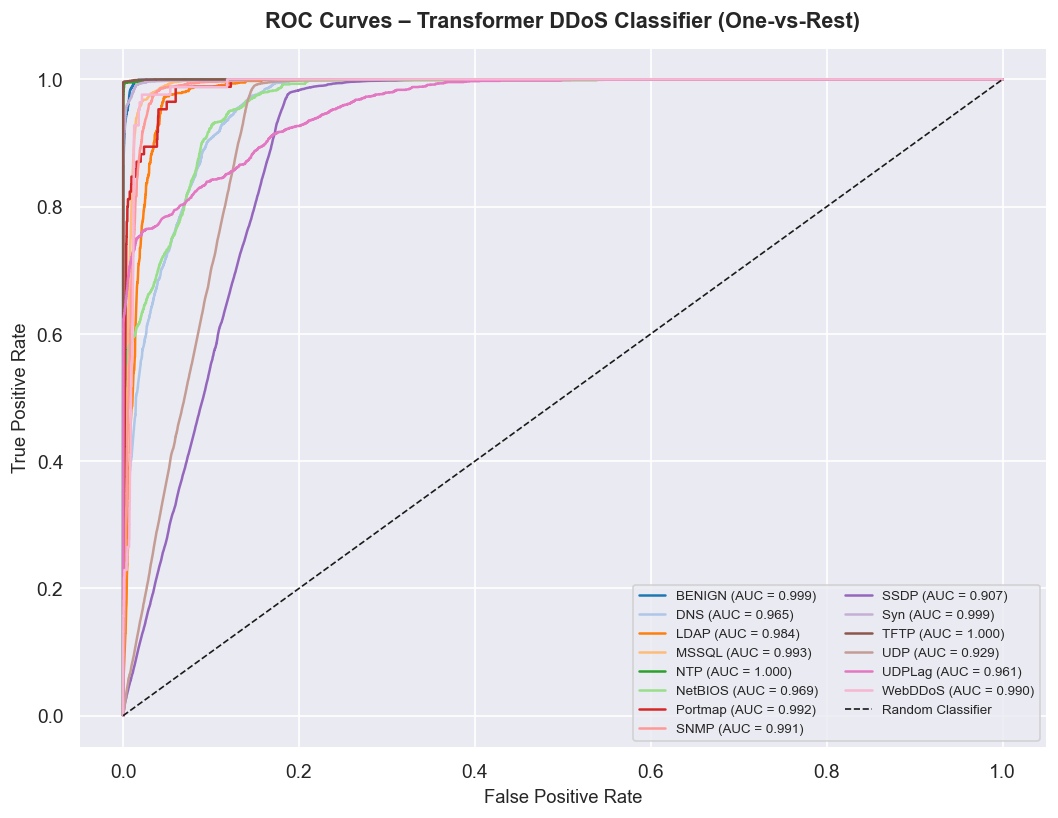

In [15]:
fig = plot_roc_curves(
    y_true_onehot=y_test,
    y_prob=y_probs,
    class_names=class_names,
    title='ROC Curves – Transformer DDoS Classifier (One-vs-Rest)',
)
fig.savefig(f'{DATA_DIR}/fig_17_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 10 · Per-Epoch Accuracy & Loss Summary Table

In [16]:
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = 'Epoch'

# Highlight best epochs
display(
    history_df.style
    .highlight_max(subset=['train_acc', 'val_acc'], color='#C8E6C9')
    .highlight_min(subset=['train_loss', 'val_loss'], color='#BBDEFB')
    .format('{:.4f}')
)

,train_loss,val_loss,train_acc,val_acc
Epoch,,,,
1,0.0717,0.0778,0.7659,0.7589
2,0.0575,0.0553,0.7997,0.8052
3,0.0559,0.0549,0.8041,0.8051
4,0.0549,0.0546,0.8066,0.8049
5,0.0542,0.0539,0.8084,0.8081
6,0.0531,0.0511,0.8112,0.8188
7,0.0518,0.0507,0.8144,0.8159
8,0.0508,0.0501,0.8173,0.8175
9,0.0503,0.0496,0.8196,0.8189


## 11 · Save Model & Artifacts

In [17]:
save_model(
    model=model,
    scaler=scaler,
    label_encoder=label_encoder,
    selected_features=selected_features,
    model_dir=MODEL_DIR,
)

print('\n=== Saved Artifacts ===')
for root, dirs, files in os.walk(MODEL_DIR):
    for fname in files:
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath)
        print(f'  {fname:<35}  {size/1024:.1f} KB')

[model_utils] Model and artifacts saved to '../../model/ddos-ids2017/'

=== Saved Artifacts ===
  label_encoder.pkl                    0.8 KB
  scaler.pkl                           5.3 KB
  selected_features.json               0.5 KB
  transformer_ddos.pt                  1129.7 KB


In [18]:
# Final summary
print('=' * 55)
print('  FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Architecture  : Transformer ({N_LAYERS} layers, {N_HEADS} heads, d={D_MODEL})')
print(f'  Input features: {n_features}')
print(f'  Output classes: {n_classes}')
print(f'  Epochs trained: {N_EPOCHS}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Macro F1      : {metrics["macro avg"]["f1-score"]*100:.2f}%')
print(f'  Weighted F1   : {metrics["weighted avg"]["f1-score"]*100:.2f}%')
print('=' * 55)

  FINAL MODEL SUMMARY
  Architecture  : Transformer (2 layers, 4 heads, d=128)
  Input features: 20
  Output classes: 14
  Epochs trained: 10
  Test Accuracy : 82.21%
  Macro F1      : 59.30%
  Weighted F1   : 78.00%


---
# Part II – Random Forest Multiclassifier

**Pipeline stages covered:**
1. Prepare integer labels from the one-hot-encoded arrays
2. Train a scikit-learn `RandomForestClassifier` on the same splits
3. Evaluation: Accuracy · Precision · Recall · F1-Score
4. Confusion matrix (raw + normalised)
5. Per-class metrics bar chart & radar chart
6. ROC curves (one-vs-rest)
7. Save RF model to `model/`

## RF-1 · Prepare Integer Labels

In [19]:
# Convert one-hot encoded labels back to integer class indices
y_train_int = np.argmax(y_train, axis=1)
y_test_int  = np.argmax(y_test,  axis=1)

print(f'y_train_int shape : {y_train_int.shape}  unique classes: {np.unique(y_train_int).tolist()}')
print(f'y_test_int  shape : {y_test_int.shape}')

y_train_int shape : (745017,)  unique classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
y_test_int  shape : (186255,)


## RF-2 · Train Random Forest

In [20]:
import time
from sklearn.ensemble import RandomForestClassifier

RF_N_ESTIMATORS     = 100
RF_MAX_DEPTH        = None   # grow full trees
RF_MIN_SAMPLES_LEAF = 2
RF_RANDOM_STATE     = RANDOM_STATE

rf_model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    class_weight='balanced',
    random_state=RF_RANDOM_STATE,
    n_jobs=-1,           # use all CPU cores
    verbose=1,
)

t0 = time.time()
rf_model.fit(X_train, y_train_int)
elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.1f}s')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   27.7s



Training complete in 83.7s


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.4min finished


## RF-3 · Evaluate on Test Set

In [21]:
from sklearn.metrics import accuracy_score

rf_y_pred = rf_model.predict(X_test)
rf_y_prob = rf_model.predict_proba(X_test)   # shape (n_samples, n_classes)

rf_test_acc = accuracy_score(y_test_int, rf_y_pred)
print(f'Test Accuracy : {rf_test_acc:.4f}  ({rf_test_acc*100:.2f}%)')

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s


Test Accuracy : 0.8061  (80.61%)


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.3s finished


In [22]:
# Full classification report
rf_metrics = compute_metrics(y_test_int, rf_y_pred, class_names)

print('=== Classification Report ===')
print(classification_report(
    y_test_int, rf_y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

=== Classification Report ===
              precision    recall  f1-score   support

      BENIGN     0.9968    0.9525    0.9742     30000
         DNS     0.6983    0.4611    0.5555      4903
        LDAP     0.3697    0.8662    0.5182      1996
       MSSQL     0.9152    0.9162    0.9157     19150
         NTP     0.9978    0.9923    0.9951     22600
     NetBIOS     0.4340    0.3026    0.3566      1140
     Portmap     0.1017    0.7529    0.1793        85
        SNMP     0.7665    0.7073    0.7357      4882
        SSDP     0.4465    0.5723    0.5016     23124
         Syn     0.9933    0.9606    0.9767     16233
        TFTP     0.9996    0.9964    0.9980     30000
         UDP     0.5924    0.4479    0.5101     30000
      UDPLag     0.5364    0.7334    0.6196      2059
     WebDDoS     0.0565    0.9277    0.1065        83

    accuracy                         0.8061    186255
   macro avg     0.6361    0.7564    0.6388    186255
weighted avg     0.8253    0.8061    0.8107    186

## RF-4 · Confusion Matrix

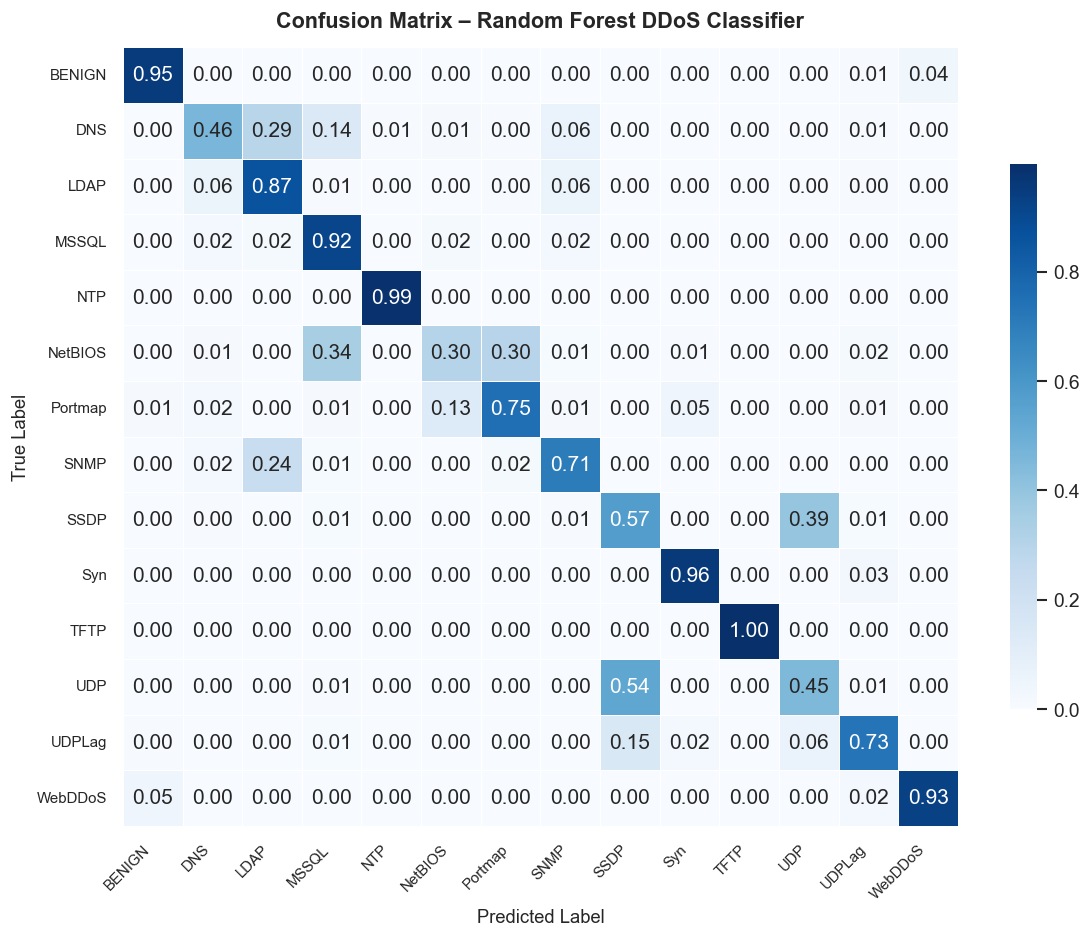

In [23]:
rf_cm = confusion_matrix(y_test_int, rf_y_pred)
fig = plot_confusion_matrix(rf_cm, class_names,
                             title='Confusion Matrix – Random Forest DDoS Classifier',
                             normalize=True)
fig.savefig(f'{DATA_DIR}/fig_rf_confusion_matrix_norm.png', dpi=120, bbox_inches='tight')
plt.show()

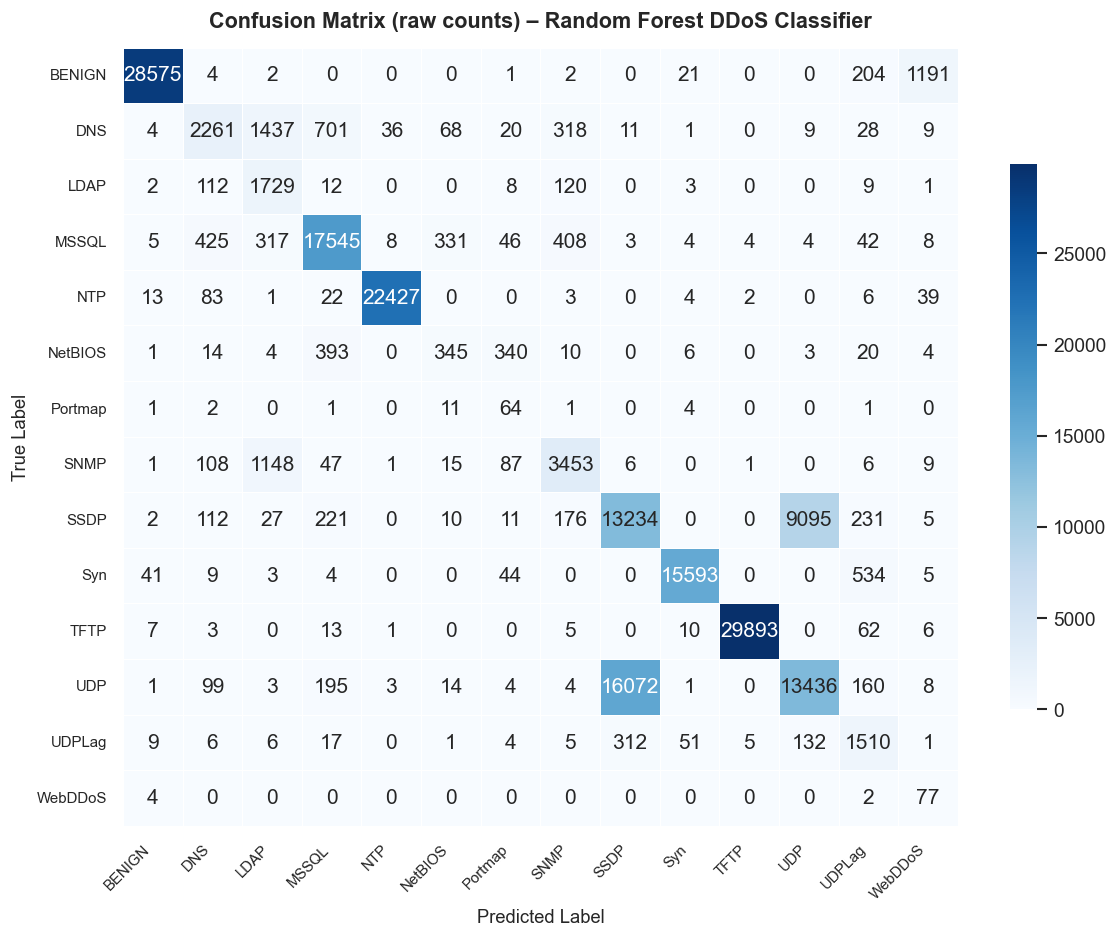

In [24]:
rf_cm = confusion_matrix(y_test_int, rf_y_pred)
fig = plot_confusion_matrix(rf_cm, class_names,
                             title='Confusion Matrix (raw counts) – Random Forest DDoS Classifier',
                             normalize=False)
fig.savefig(f'{DATA_DIR}/fig_rf_confusion_matrix_raw.png', dpi=120, bbox_inches='tight')
plt.show()

## RF-5 · Per-Class Metrics

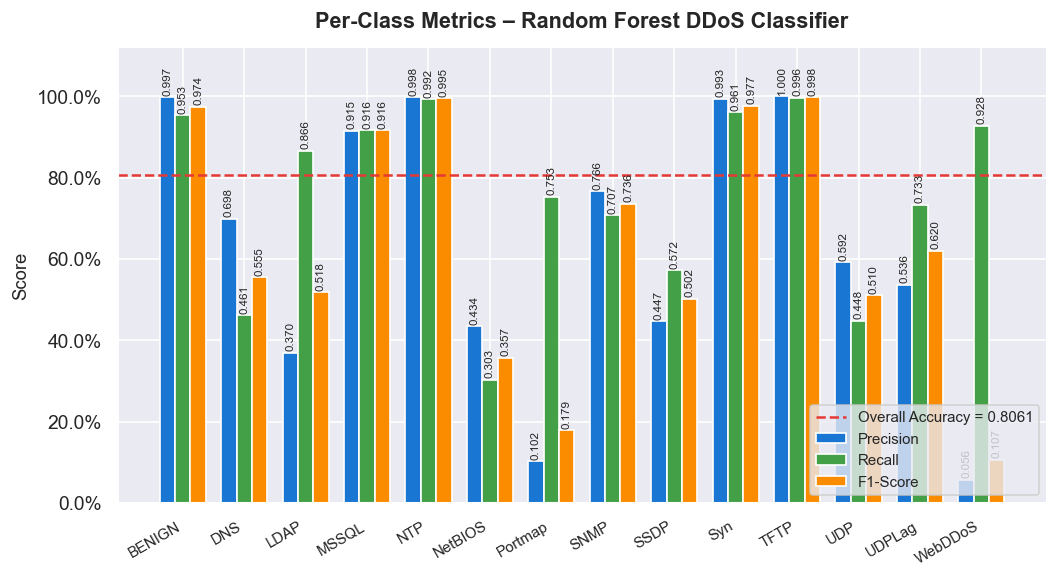

In [25]:
fig = plot_evaluation_metrics(
    metrics=rf_metrics,
    title='Per-Class Metrics – Random Forest DDoS Classifier',
)
fig.savefig(f'{DATA_DIR}/fig_rf_per_class_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

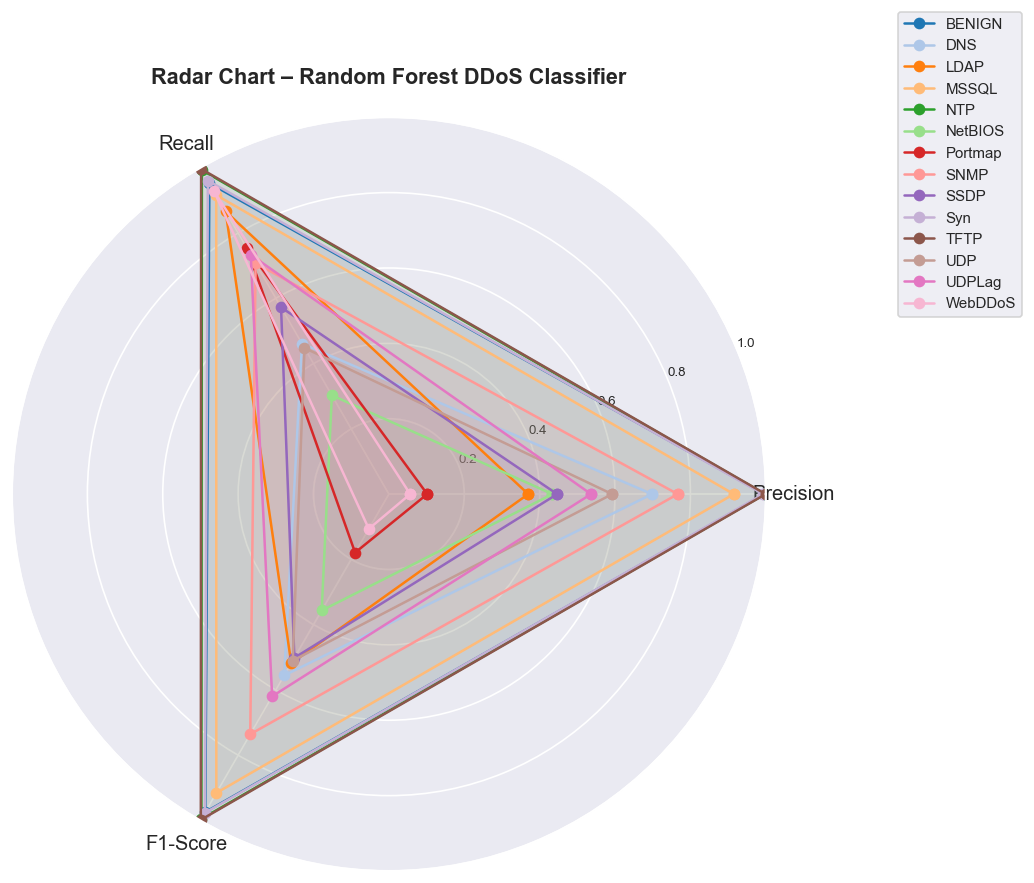

In [26]:
fig = plot_metrics_radar(
    metrics=rf_metrics,
    title='Radar Chart – Random Forest DDoS Classifier',
)
fig.savefig(f'{DATA_DIR}/fig_rf_radar.png', dpi=120, bbox_inches='tight')
plt.show()

## RF-6 · ROC Curves (One-vs-Rest)

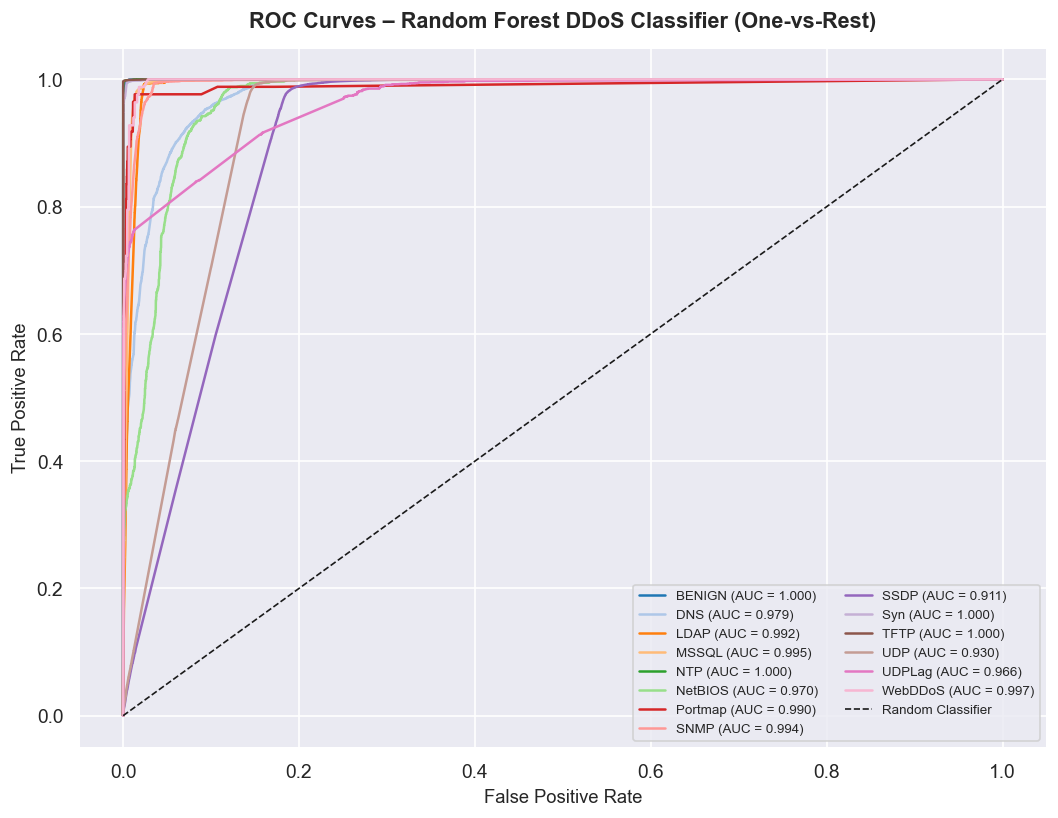

In [27]:
fig = plot_roc_curves(
    y_true_onehot=y_test,
    y_prob=rf_y_prob,
    class_names=class_names,
    title='ROC Curves – Random Forest DDoS Classifier (One-vs-Rest)',
)
fig.savefig(f'{DATA_DIR}/fig_rf_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## RF-7 · Save Random Forest Model

In [28]:
import joblib, os

rf_model_path = os.path.join(MODEL_DIR, 'random_forest_ddos.pkl')
joblib.dump(rf_model, rf_model_path)
print(f'Random Forest model saved to: {rf_model_path}')
size_kb = os.path.getsize(rf_model_path) / 1024
print(f'File size: {size_kb:.1f} KB')

print('\n=== Saved Artifacts ===')
for root, dirs, files in os.walk(MODEL_DIR):
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath)
        print(f'  {fname:<40}  {size/1024:.1f} KB')

Random Forest model saved to: ../../model/ddos-ids2017\random_forest_ddos.pkl
File size: 311587.3 KB

=== Saved Artifacts ===
  label_encoder.pkl                         0.8 KB
  random_forest_ddos.pkl                    311587.3 KB
  scaler.pkl                                5.3 KB
  selected_features.json                    0.5 KB
  transformer_ddos.pt                       1129.7 KB


In [29]:
# Final RF summary
print('=' * 55)
print('  FINAL RANDOM FOREST MODEL SUMMARY')
print('=' * 55)
print(f'  Algorithm     : RandomForestClassifier')
print(f'  N estimators  : {RF_N_ESTIMATORS}')
print(f'  Max depth     : {RF_MAX_DEPTH}')
print(f'  Input features: {n_features}')
print(f'  Output classes: {n_classes}')
print(f'  Test Accuracy : {rf_test_acc*100:.2f}%')
print(f'  Macro F1      : {rf_metrics["macro avg"]["f1-score"]*100:.2f}%')
print(f'  Weighted F1   : {rf_metrics["weighted avg"]["f1-score"]*100:.2f}%')
print('=' * 55)

  FINAL RANDOM FOREST MODEL SUMMARY
  Algorithm     : RandomForestClassifier
  N estimators  : 100
  Max depth     : None
  Input features: 20
  Output classes: 14
  Test Accuracy : 80.61%
  Macro F1      : 63.88%
  Weighted F1   : 81.07%
